<a href="https://colab.research.google.com/github/renato2007-hub/online-retail-ml/blob/main/Modelo_basico_BVQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BOLSA DE VALORES DE QUITO

**Problema de Negocio**
Determinar el momento óptimo de compra y venta de acciones en la Bolsa de Valores de Quito, identificando qué emisor ofrece la mayor probabilidad de ganancia en el siguiente día hábil, con el fin de maximizar el retorno de inversión y minimizar pérdidas mediante una estrategia de decisión basada en Machine Learning.

**Variable Objetivo:**
Variable binaria que indica la dirección del precio en el siguiente día hábil operativo.
Valor Significado Acción 1.- El precio subirá 🟢 Señal de COMPRA 2.- El precio bajará🔴 Señal de VENTA / NO COMPRAR

CLASIFICACION BINARIA SUPERVISADA

Horizonte de predicciónSiguiente día hábil (gap ≤ 7 días)

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Para que pandas muestre más columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Cargar datos
bd_BVQ = pd.read_excel('/content/Base_de_datos_Bolsa_Valores_Quito.xls')

# Información general
print(f"Shape: {bd_BVQ.shape}")
print(f"\nTipos de datos:")
print(bd_BVQ.dtypes)
print(f"\nPrimeras filas:")
bd_BVQ.head()

Shape: (8241, 9)

Tipos de datos:
Unnamed: 0    float64
Unnamed: 1     object
Unnamed: 2     object
Unnamed: 3     object
Unnamed: 4     object
Unnamed: 5     object
Unnamed: 6     object
Unnamed: 7     object
Unnamed: 8     object
dtype: object

Primeras filas:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,FECHA,EMISOR,VALOR,VALOR NOMINAL,PRECIO,NUMERO ACCIONES,VALOR EFECTIVO,PROCEDENCIA
1,NaN,2025-01-06 00:00:00,CORPORACION FAVORITA C.A.,ACCIONES,1,1.88,4255,7999.4,Q
2,NaN,2025-01-06 00:00:00,BANCO PICHINCHA C.A.,ACCIONES,100,85,25,2125,G
3,NaN,2025-01-06 00:00:00,CORPORACION FAVORITA C.A.,ACCIONES,1,1.88,1552,2917.76,Q
4,NaN,2025-01-06 00:00:00,BOLSA DE VALORES DE QUITO,ACCIONES,1,3.05,639,1948.95,Q


In [3]:
# Eliminar la columna 'Unnamed: 0' ya que no contiene información útil.
bd_BVQ = bd_BVQ.drop(columns=['Unnamed: 0'])

# Establecer la primera fila como encabezados de columna.
bd_BVQ.columns = bd_BVQ.iloc[0]

# Eliminar la primera fila (que ahora es el encabezado duplicado).
bd_BVQ = bd_BVQ[1:].reset_index(drop=True)

# Mostrar información general y las primeras filas del DataFrame limpio
print(f"Shape: {bd_BVQ.shape}")
print(f"\nTipos de datos:")
print(bd_BVQ.dtypes)
print(f"\nPrimeras filas:")
bd_BVQ.head()

Shape: (8240, 8)

Tipos de datos:
0
FECHA              object
EMISOR             object
VALOR              object
VALOR NOMINAL      object
PRECIO             object
NUMERO ACCIONES    object
VALOR EFECTIVO     object
PROCEDENCIA        object
dtype: object

Primeras filas:


,FECHA,EMISOR,VALOR,VALOR NOMINAL,PRECIO,NUMERO ACCIONES,VALOR EFECTIVO,PROCEDENCIA
0,2025-01-06 00:00:00,CORPORACION FAVORITA C.A.,ACCIONES,1,1.88,4255,7999.4,Q
1,2025-01-06 00:00:00,BANCO PICHINCHA C.A.,ACCIONES,100,85,25,2125,G
2,2025-01-06 00:00:00,CORPORACION FAVORITA C.A.,ACCIONES,1,1.88,1552,2917.76,Q
3,2025-01-06 00:00:00,BOLSA DE VALORES DE QUITO,ACCIONES,1,3.05,639,1948.95,Q
4,2025-01-06 00:00:00,BANCO BOLIVARIANO C.A.,ACCIONES,1,1.1,15000,16500,G


In [4]:
# Usar describe() para obtener estadísticas descriptivas del DataFrame
display(bd_BVQ.describe(include='all'))

,FECHA,EMISOR,VALOR,VALOR NOMINAL,PRECIO,NUMERO ACCIONES,VALOR EFECTIVO,PROCEDENCIA
count,8240,8240,8240,8240,8240,8240,8240,8240
unique,285,52,4,7,611,2602,4396,2
top,2025-06-20 00:00:00,MUTUALISTA PICHINCHA,ACCIONES,1,100,1,100,Q
freq,106,2244,5466,5371,1609,1532,1020,6589


In [5]:
# Usar info() para obtener un resumen del DataFrame
bd_BVQ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   FECHA            8240 non-null   object
 1   EMISOR           8240 non-null   object
 2   VALOR            8240 non-null   object
 3   VALOR NOMINAL    8240 non-null   object
 4   PRECIO           8240 non-null   object
 5   NUMERO ACCIONES  8240 non-null   object
 6   VALOR EFECTIVO   8240 non-null   object
 7   PROCEDENCIA      8240 non-null   object
dtypes: object(8)
memory usage: 515.1+ KB


Convertir columnas STR

In [6]:
cols_numericas = [
    "VALOR NOMINAL",
    "PRECIO",
    "NUMERO ACCIONES",
    "VALOR EFECTIVO"
]

for col in cols_numericas:
    bd_BVQ[col] = (
        bd_BVQ[col]
        .astype(str)                          # fuerza a string
        .str.replace(".", "", regex=False)   # elimina separador miles
        .str.replace(",", ".", regex=False)  # cambia coma decimal
    )

    bd_BVQ[col] = pd.to_numeric(bd_BVQ[col], errors="coerce")

In [7]:
bd_BVQ.info()
bd_BVQ.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   FECHA            8240 non-null   object
 1   EMISOR           8240 non-null   object
 2   VALOR            8240 non-null   object
 3   VALOR NOMINAL    8240 non-null   int64 
 4   PRECIO           8240 non-null   int64 
 5   NUMERO ACCIONES  8240 non-null   int64 
 6   VALOR EFECTIVO   8240 non-null   int64 
 7   PROCEDENCIA      8240 non-null   object
dtypes: int64(4), object(4)
memory usage: 515.1+ KB


,0
0,
FECHA,0
EMISOR,0
VALOR,0
VALOR NOMINAL,0
PRECIO,0
NUMERO ACCIONES,0
VALOR EFECTIVO,0
PROCEDENCIA,0


cambiar fecha a datatime

In [8]:
bd_BVQ["FECHA"] = pd.to_datetime(bd_BVQ["FECHA"], dayfirst=True)

In [9]:
bd_BVQ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   FECHA            8240 non-null   datetime64[ns]
 1   EMISOR           8240 non-null   object        
 2   VALOR            8240 non-null   object        
 3   VALOR NOMINAL    8240 non-null   int64         
 4   PRECIO           8240 non-null   int64         
 5   NUMERO ACCIONES  8240 non-null   int64         
 6   VALOR EFECTIVO   8240 non-null   int64         
 7   PROCEDENCIA      8240 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 515.1+ KB


cambiar precio a float

In [10]:
bd_BVQ["PRECIO"] = bd_BVQ["PRECIO"].astype(float)
bd_BVQ["VALOR NOMINAL"] = bd_BVQ["VALOR NOMINAL"].astype(float)
bd_BVQ["NUMERO ACCIONES"] = bd_BVQ["NUMERO ACCIONES"].astype(float)
bd_BVQ["VALOR EFECTIVO"] = bd_BVQ["VALOR EFECTIVO"].astype(float)

convertir categóricas

In [11]:
bd_BVQ["EMISOR"] = bd_BVQ["EMISOR"].astype("category")
bd_BVQ["VALOR"] = bd_BVQ["VALOR"].astype("category")
bd_BVQ["PROCEDENCIA"] = bd_BVQ["PROCEDENCIA"].astype("category")

In [12]:
bd_BVQ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   FECHA            8240 non-null   datetime64[ns]
 1   EMISOR           8240 non-null   category      
 2   VALOR            8240 non-null   category      
 3   VALOR NOMINAL    8240 non-null   float64       
 4   PRECIO           8240 non-null   float64       
 5   NUMERO ACCIONES  8240 non-null   float64       
 6   VALOR EFECTIVO   8240 non-null   float64       
 7   PROCEDENCIA      8240 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(4)
memory usage: 348.9 KB


In [13]:
bd_BVQ["EMISOR"].value_counts().head(10)

,count
EMISOR,
MUTUALISTA PICHINCHA,2244
CORPORACION FAVORITA C.A.,2205
BANCO GUAYAQUIL S.A.,903
BANCO DE LA PRODUCCION S.A . PRODUBANCO,532
FONDO DE INVERSION COTIZADO ETF,330
BANCO PICHINCHA C.A.,286
INVERSANCARLOS,205
BOLSA DE VALORES DE QUITO,182
CERVECERIA NACIONAL CN S A,174


UNIDAD DE OBSERVACIÓN

### Revisión de Duplicados

In [14]:
# Contar el número de filas duplicadas
num_duplicates = bd_BVQ.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame: {num_duplicates}")

# Mostrar algunas de las filas duplicadas (si existen)
if num_duplicates > 0:
    print("\nEjemplo de filas duplicadas (primeras 5):")
    display(bd_BVQ[bd_BVQ.duplicated(keep=False)].head())
else:
    print("\nNo se encontraron filas duplicadas en el DataFrame.")

Número de filas duplicadas en el DataFrame: 2321

Ejemplo de filas duplicadas (primeras 5):


,FECHA,EMISOR,VALOR,VALOR NOMINAL,PRECIO,NUMERO ACCIONES,VALOR EFECTIVO,PROCEDENCIA
21,2025-01-09,MUTUALISTA PICHINCHA,CERTIFICADOS DE APORTACION,100.0,100.0,1.0,100.0,Q
23,2025-01-09,MUTUALISTA PICHINCHA,CERTIFICADOS DE APORTACION,100.0,100.0,1.0,100.0,Q
25,2025-01-09,MUTUALISTA PICHINCHA,CERTIFICADOS DE APORTACION,100.0,100.0,1.0,100.0,Q
27,2025-01-09,MUTUALISTA PICHINCHA,CERTIFICADOS DE APORTACION,100.0,100.0,1.0,100.0,Q
29,2025-01-09,MUTUALISTA PICHINCHA,CERTIFICADOS DE APORTACION,100.0,100.0,1.0,100.0,Q


### Revisión de Valores Únicos por Columna

In [15]:
# Contar valores únicos por cada columna
print("Número de valores únicos por columna:")
display(bd_BVQ.nunique())

Número de valores únicos por columna:


,0
0,
FECHA,285
EMISOR,52
VALOR,4
VALOR NOMINAL,7
PRECIO,558
NUMERO ACCIONES,2602
VALOR EFECTIVO,4307
PROCEDENCIA,2


DEBO VERIFICAR SI SON DUPLICADOS EXACTOS O QUE PASA CON EL DF

In [16]:
bd_BVQ.duplicated(subset=[
    "FECHA",
    "EMISOR",
    "VALOR",
    "VALOR NOMINAL",
    "PRECIO",
    "NUMERO ACCIONES",
    "VALOR EFECTIVO",
    "PROCEDENCIA"
]).sum()

np.int64(2321)

OBSERVACIÓN: A largo plazo los valores duplicados van a causar errores de sobreestimación, alterar medias, introducir sesgos

**DESICIÓN**: Hay que eliminar duplicados

In [17]:
bd_BVQ = bd_BVQ.drop_duplicates()
bd_BVQ.shape

(5919, 8)

VALORES

In [18]:
bd_BVQ["VALOR"].value_counts()

,count
VALOR,
ACCIONES,5241
CUOTAS DE PARTICIPACION,441
CERTIFICADOS DE APORTACION,210
ACCIONES PREFERIDAS,27


ANÁLISIS DE FECHAS

In [19]:
bd_BVQ.groupby("FECHA").size().describe()

,0
count,285.000000
mean,20.768421
std,8.789542
min,3.000000
25%,14.000000
50%,21.000000
75%,27.000000
max,49.000000


ANÁLISIS POR EMISOR

In [20]:
bd_BVQ["EMISOR"].value_counts().describe()

,count
count,52.000000
mean,113.826923
std,320.225026
min,1.000000
25%,3.000000
50%,10.500000
75%,91.500000
max,2122.000000


QUIEN CONCENTRA LA LIQUIDÉZ

In [21]:
bd_BVQ["EMISOR"].value_counts().head(20)

,count
EMISOR,
CORPORACION FAVORITA C.A.,2122
BANCO GUAYAQUIL S.A.,855
BANCO DE LA PRODUCCION S.A . PRODUBANCO,503
FONDO DE INVERSION COTIZADO ETF,321
BANCO PICHINCHA C.A.,266
MUTUALISTA PICHINCHA,210
INVERSANCARLOS,204
CERVECERIA NACIONAL CN S A,173
NATLUK SA,171


El precio de los emisores líquidos es estable o volátil?

In [22]:
bd_BVQ[bd_BVQ["EMISOR"] == "CORPORACION FAVORITA C.A."]["PRECIO"].describe()

,PRECIO
count,2122.000000
mean,177.305844
std,40.904153
min,0.000000
25%,185.000000
50%,186.000000
75%,189.000000
max,201.000000


OBSERVACIÓN: Hay valores cero en precios de acciones

ACCIONES DE LA FAVORITA CON PRECIO 0

In [23]:
bd_BVQ[
    (bd_BVQ["EMISOR"] == "CORPORACION FAVORITA C.A.") &
    (bd_BVQ["PRECIO"] == 0)
].shape

(3, 8)

**DESICIÓN**: Eliminar los CEROS

In [24]:
bd_cf = bd_BVQ[
    (bd_BVQ["EMISOR"] == "CORPORACION FAVORITA C.A.") &
    (bd_BVQ["PRECIO"] > 0)
].copy()
bd_cf["PRECIO"].describe()

,PRECIO
count,2119.000000
mean,177.556866
std,40.384746
min,2.000000
25%,185.000000
50%,186.000000
75%,189.000000
max,201.000000


**COHERENCIA DE LOS DATOS**



Variables categóricas

Variables categóricas a graficar: ['VALOR', 'PROCEDENCIA']


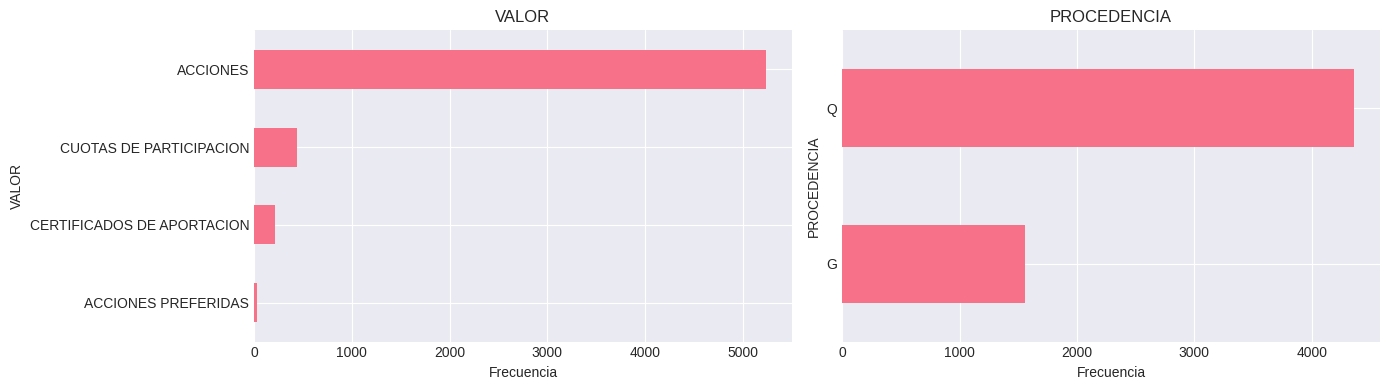

In [25]:
# Identificar variables categóricas (object)
var_categoricas = bd_BVQ.select_dtypes(include=['category']).columns.tolist()
# Excluir 'EMISOR' de este gráfico general ya que se hará uno específico para los top 20.
if 'EMISOR' in var_categoricas:
    var_categoricas.remove('EMISOR')

print(f"Variables categóricas a graficar: {var_categoricas}")

# Visualizar distribución de variables categóricas (excluyendo EMISOR)
n_vars = len(var_categoricas)

# Asegurar que n_vars no sea cero para evitar errores si no hay variables que graficar
if n_vars > 0:
    fig, axes = plt.subplots(nrows=(n_vars + 1) // 2, ncols=2, figsize=(14, 4 * ((n_vars + 1) // 2)))
    axes = axes.flatten()

    for i, var in enumerate(var_categoricas):
        conteo = bd_BVQ[var].value_counts().sort_values(ascending=True)
        conteo.plot(kind='barh', ax=axes[i], title=var)
        axes[i].set_xlabel('Frecuencia')

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No hay variables categóricas para graficar después de excluir 'EMISOR'.")

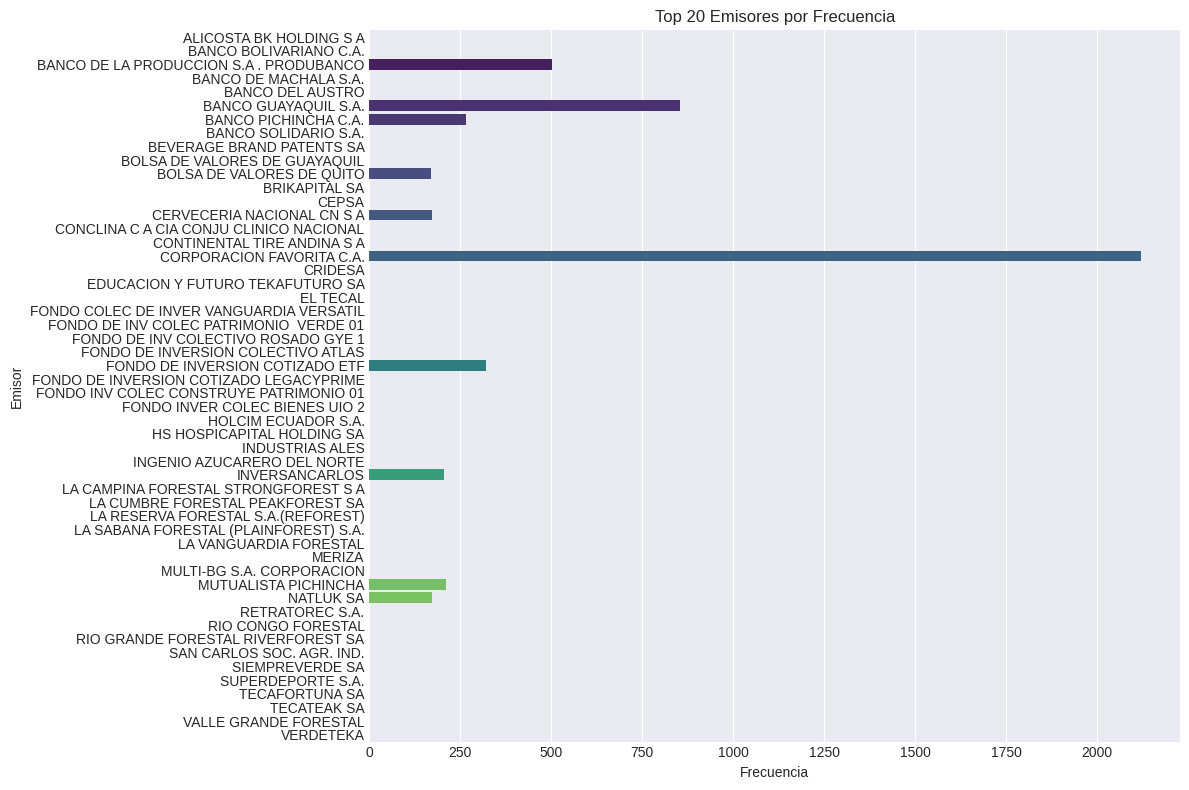

In [26]:
# Graficar los 10 principales emisores
plt.figure(figsize=(12, 8))
top_20_emisores = bd_BVQ['EMISOR'].value_counts().head(10).sort_values(ascending=True)
sns.barplot(x=top_20_emisores.values, y=top_20_emisores.index, palette='viridis')
plt.title('Top 20 Emisores por Frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Emisor')
plt.tight_layout()
plt.show()

Variables numéricas

In [27]:
# Identificar variables numéricas
var_numericas = bd_BVQ.select_dtypes(include=[np.number]).columns.tolist()
if 'PRECIO' in var_numericas:
    var_numericas.remove('PRECIO')

print(f"Total de variables numéricas: {len(var_numericas)}")
print(f"Variables: {var_numericas}")

Total de variables numéricas: 3
Variables: ['VALOR NOMINAL', 'NUMERO ACCIONES', 'VALOR EFECTIVO']


IDENTIFICAR EMISORES CON BAJA FRECUENCIA

In [28]:
emisor_counts = bd_BVQ["EMISOR"].value_counts()

emisores_pocos = emisor_counts[emisor_counts < 30]
emisores_pocos

,count
EMISOR,
FONDO DE INV COLEC PATRIMONIO VERDE 01,26
BRIKAPITAL SA,23
VERDETEKA,22
INDUSTRIAS ALES,22
CRIDESA,12
BANCO DE MACHALA S.A.,11
TECAFORTUNA SA,11
FONDO DE INVERSION COLECTIVO ATLAS,10
SIEMPREVERDE SA,8


PORCENTAJE QUE REPRESENTAN

In [29]:
emisores_pocos.sum() / len(bd_BVQ)

np.float64(0.03598580841358338)

GRAFICO

<Axes: >

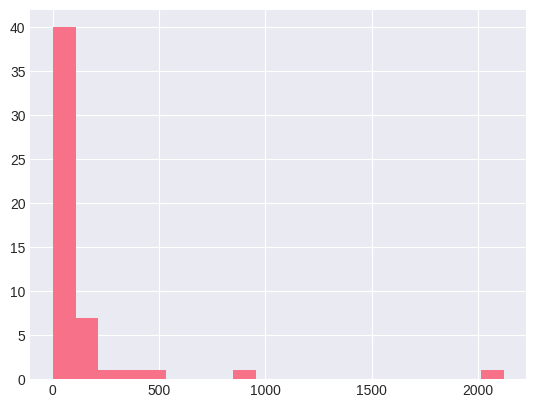

In [30]:
emisor_counts.hist(bins=20)

La distribución de transacciones por emisor presenta fuerte asimetría positiva, evidenciando alta concentración de liquidez en pocos activos y una larga cola de emisores con actividad marginal.

**DESICIÓN**: ELIMINAR los datos que aportan ruido y conservar el 96.4% de los datos

In [31]:
# ¿Cuántas transacciones mínimas consideras "suficiente"?
# Sugerencia: al menos 30 transacciones por emisor

umbral = 30  # ajusta según tu criterio

emisores_validos = bd_BVQ["EMISOR"].value_counts()
emisores_validos = emisores_validos[emisores_validos >= umbral].index

bd_BVQ_clean = bd_BVQ[bd_BVQ["EMISOR"].isin(emisores_validos)].copy()

print(f"Emisores antes: {bd_BVQ['EMISOR'].nunique()}")
print(f"Emisores después: {bd_BVQ_clean['EMISOR'].nunique()}")
print(f"Registros conservados: {len(bd_BVQ_clean)} ({len(bd_BVQ_clean)/len(bd_BVQ)*100:.1f}%)")

Emisores antes: 52
Emisores después: 19
Registros conservados: 5706 (96.4%)


Verificar distribución por emisor

In [32]:
resumen_emisores = (
    bd_BVQ_clean.groupby("EMISOR")
    .agg(
        transacciones   = ("PRECIO", "count"),
        fecha_inicio    = ("FECHA", "min"),
        fecha_fin       = ("FECHA", "max"),
        precio_promedio = ("PRECIO", "mean"),
        precio_std      = ("PRECIO", "std"),
        valor_total     = ("VALOR EFECTIVO", "sum")
    )
    .sort_values("transacciones", ascending=False)
    .reset_index()
)

# Calcular días de historia
resumen_emisores["dias_historia"] = (
    resumen_emisores["fecha_fin"] - resumen_emisores["fecha_inicio"]
).dt.days

# Coeficiente de variación (proxy de volatilidad)
resumen_emisores["CV_%"] = (
    resumen_emisores["precio_std"] / resumen_emisores["precio_promedio"] * 100
).round(2)

display(resumen_emisores)

,EMISOR,transacciones,fecha_inicio,fecha_fin,precio_promedio,precio_std,valor_total,dias_historia,CV_%
0,CORPORACION FAVORITA C.A.,2122,2025-01-06,2026-02-27,1.773058e+02,4.090415e+01,2.005690e+09,417.0,23.07
1,BANCO GUAYAQUIL S.A.,855,2025-01-08,2026-02-27,1.241977e+02,6.454931e+01,2.321946e+08,415.0,51.97
2,BANCO DE LA PRODUCCION S.A . PRODUBANCO,503,2025-01-07,2026-02-27,7.224254e+01,4.505053e+01,1.231684e+08,416.0,62.36
3,FONDO DE INVERSION COTIZADO ETF,321,2025-01-30,2026-02-27,7.805753e+07,4.405821e+07,3.024092e+09,393.0,56.44
4,BANCO PICHINCHA C.A.,266,2025-01-06,2026-02-27,1.133053e+03,2.794150e+03,1.685062e+07,417.0,246.60
5,MUTUALISTA PICHINCHA,210,2025-01-09,2026-01-27,9.912381e+01,1.828510e+00,6.898100e+04,383.0,1.84
6,INVERSANCARLOS,204,2025-01-14,2026-02-27,1.685441e+02,1.250934e+02,4.859297e+07,409.0,74.22
7,CERVECERIA NACIONAL CN S A,173,2025-01-08,2026-02-24,2.450462e+02,9.027158e+02,1.623581e+06,412.0,368.39
8,NATLUK SA,171,2025-01-07,2026-02-24,7.700000e+01,0.000000e+00,5.148990e+05,413.0,0.00
9,BOLSA DE VALORES DE QUITO,170,2025-01-06,2026-02-19,2.071647e+02,1.649986e+02,3.592672e+07,409.0,79.65


In [33]:
# 1. Verificar BANCO PICHINCHA - CV 246% es sospechoso
bd_BVQ_clean[bd_BVQ_clean["EMISOR"] == "BANCO PICHINCHA C.A."]["PRECIO"].describe()

,PRECIO
count,266.000000
mean,1133.052632
std,2794.149819
min,78.000000
25%,86.250000
50%,90.000000
75%,111.000000
max,9602.000000


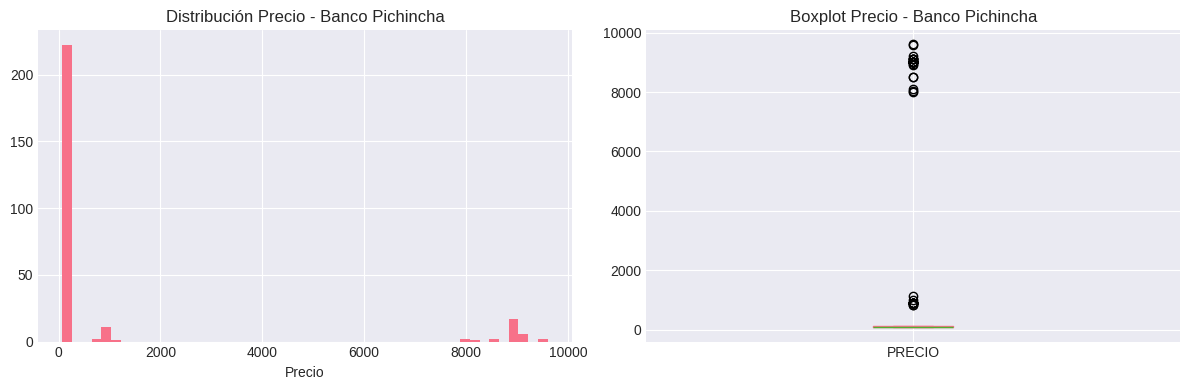

Registros con precio > 500: 44
Registros con precio > 1000: 32
Registros con precio <= 200: 222


In [34]:
# Ver la distribución real
import matplotlib.pyplot as plt

bp = bd_BVQ_clean[bd_BVQ_clean["EMISOR"] == "BANCO PICHINCHA C.A."]["PRECIO"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bp.hist(bins=50, ax=axes[0])
axes[0].set_title("Distribución Precio - Banco Pichincha")
axes[0].set_xlabel("Precio")

bp.plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot Precio - Banco Pichincha")

plt.tight_layout()
plt.show()

# Cuántos registros tienen precio > 500?
print("Registros con precio > 500:", (bp > 500).sum())
print("Registros con precio > 1000:", (bp > 1000).sum())
print("Registros con precio <= 200:", (bp <= 200).sum())

222 registros Normales y 44 outliers

mantenemos porque pueden ser otros instrumentos financieros

In [35]:
# Limpiar Pichincha conservando solo precios coherentes
mask_pichincha = (
    (bd_BVQ_clean["EMISOR"] == "BANCO PICHINCHA C.A.") &
    (bd_BVQ_clean["PRECIO"] > 500)
)

bd_BVQ_clean = bd_BVQ_clean[~mask_pichincha].copy()

# Verificar resultado
print(bd_BVQ_clean[bd_BVQ_clean["EMISOR"] == "BANCO PICHINCHA C.A."]["PRECIO"].describe())
print(f"\nRegistros totales restantes: {len(bd_BVQ_clean)}")

count    222.000000
mean      93.139640
std       11.254094
min       78.000000
25%       85.000000
50%       90.000000
75%      100.000000
max      117.000000
Name: PRECIO, dtype: float64

Registros totales restantes: 5662


## Analizar 'PRECIO' de ETF

### Subtask:
Filtrar el DataFrame `bd_BVQ_clean` para el emisor 'FONDO DE INVERSION COTIZADO ETF' y obtener las estadísticas descriptivas de la columna 'PRECIO' para entender su rango, media, desviación estándar, etc.


**Reasoning**:
The subtask requires filtering the `bd_BVQ_clean` DataFrame for a specific 'EMISOR' and then obtaining descriptive statistics for the 'PRECIO' column. This will be done in a single code block.



In [36]:
etf_data = bd_BVQ_clean[bd_BVQ_clean["EMISOR"] == "FONDO DE INVERSION COTIZADO ETF"]
etf_data["PRECIO"].describe()

,PRECIO
count,3.210000e+02
mean,7.805753e+07
std,4.405821e+07
min,1.000000e+00
25%,1.062443e+07
50%,1.031500e+08
75%,1.049771e+08
max,1.084146e+08


**Reasoning**:
The next step is to visualize the distribution of the 'PRECIO' column for the 'FONDO DE INVERSION COTIZADO ETF' using a histogram and a box plot, as specified in the main task, to identify outliers and understand its distribution. This will help us further analyze the data coherence.



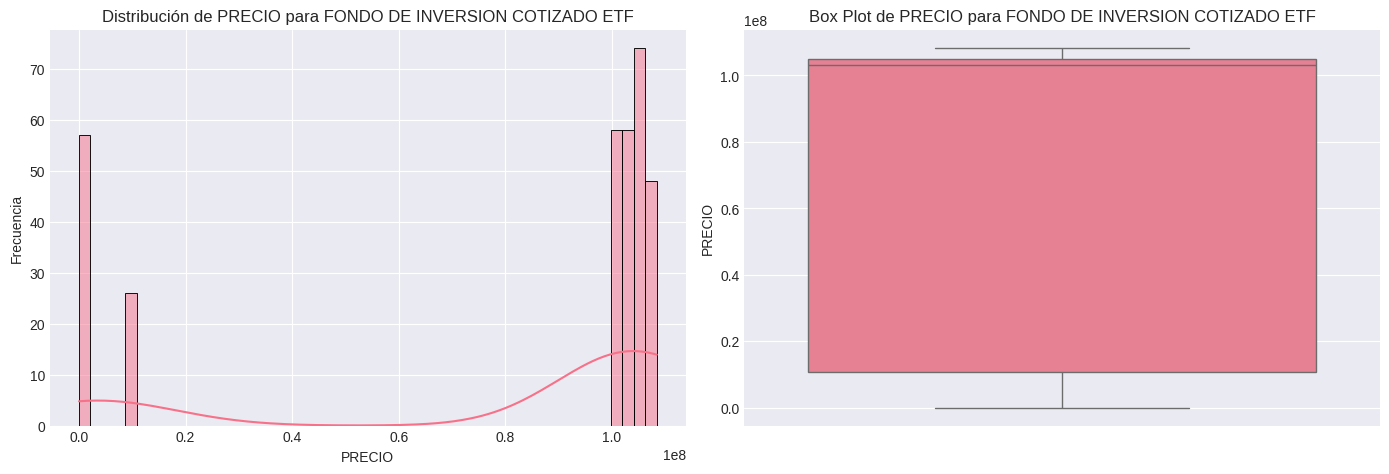

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for histogram and box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(etf_data['PRECIO'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribución de PRECIO para FONDO DE INVERSION COTIZADO ETF')
axes[0].set_xlabel('PRECIO')
axes[0].set_ylabel('Frecuencia')

# Box Plot
sns.boxplot(y=etf_data['PRECIO'], ax=axes[1])
axes[1].set_title('Box Plot de PRECIO para FONDO DE INVERSION COTIZADO ETF')
axes[1].set_ylabel('PRECIO')

plt.tight_layout()
plt.show()

### Observación y Decisión sobre 'PRECIO' de 'FONDO DE INVERSION COTIZADO ETF'

La distribución del `PRECIO` para el 'FONDO DE INVERSION COTIZADO ETF' es altamente asimétrica. Las estadísticas descriptivas muestran un `PRECIO` mínimo de 1.0 y un máximo de 1.08e+08, con una desviación estándar muy alta (4.4e+07) en comparación con la media (7.8e+07).

El histograma y el box plot confirman la presencia de **valores atípicos extremos** (outliers) en el lado inferior, indicando que la mayoría de los precios son altos, pero hay un subconjunto de transacciones con precios extraordinariamente bajos. Esto es similar al caso del 'BANCO PICHINCHA C.A.', donde se identificaron valores atípicos que podrían corresponder a diferentes instrumentos o errores en la captura de datos.

**Decisión**: Es necesario investigar estos valores atípicos. Para mantener la coherencia del análisis, se debe considerar la eliminación de estos precios extremadamente bajos, o al menos separarlos si representan un tipo de transacción o instrumento diferente que no se alinea con la mayoría de los datos del ETF. Esto garantizará que las métricas estadísticas y los análisis posteriores no estén sesgados por estos valores extremos.

In [38]:
# Eliminar ETF y NATLUK y VANGUARDIA (CV=0)
emisores_eliminar = [
    "FONDO DE INVERSION COTIZADO ETF",
    "NATLUK SA",
    "FONDO COLEC DE INVER VANGUARDIA VERSATIL",
    "FONDO DE INVERSION COTIZADO LEGACYPRIME",  # precios en millones, mismo problema
]

bd_modelo = bd_BVQ_clean[~bd_BVQ_clean["EMISOR"].isin(emisores_eliminar)].copy()

print(f"Emisores finales: {bd_modelo['EMISOR'].nunique()}")
print(f"Registros finales: {len(bd_modelo)}")
print(f"\nDistribución por emisor:")
print(bd_modelo['EMISOR'].value_counts())

Emisores finales: 15
Registros finales: 5097

Distribución por emisor:
EMISOR
CORPORACION FAVORITA C.A.                   2122
BANCO GUAYAQUIL S.A.                         855
BANCO DE LA PRODUCCION S.A . PRODUBANCO      503
BANCO PICHINCHA C.A.                         222
MUTUALISTA PICHINCHA                         210
INVERSANCARLOS                               204
CERVECERIA NACIONAL CN S A                   173
BOLSA DE VALORES DE QUITO                    170
HOLCIM ECUADOR S.A.                          137
BANCO BOLIVARIANO C.A.                       116
CONCLINA C A CIA CONJU CLINICO NACIONAL       99
BOLSA DE VALORES DE GUAYAQUIL                 89
BEVERAGE BRAND PATENTS SA                     82
BANCO DEL AUSTRO                              59
SAN CARLOS SOC. AGR. IND.                     56
CEPSA                                          0
BANCO DE MACHALA S.A.                          0
BANCO SOLIDARIO S.A.                           0
BRIKAPITAL SA                           

In [39]:
# Limpiar categorías vacías
bd_modelo["EMISOR"] = bd_modelo["EMISOR"].cat.remove_unused_categories()

print(f"Emisores finales: {bd_modelo['EMISOR'].nunique()}")
print(f"Registros finales: {len(bd_modelo)}")

Emisores finales: 15
Registros finales: 5097


In [40]:
# Revisar los tres de una vez
for emisor in ["CONCLINA C A CIA CONJU CLINICO NACIONAL",
               "CERVECERIA NACIONAL CN S A",
               "HOLCIM ECUADOR S.A."]:
    print(f"\n{'='*50}")
    print(f"{emisor}")
    print(bd_modelo[bd_modelo["EMISOR"] == emisor]["PRECIO"].describe())


CONCLINA C A CIA CONJU CLINICO NACIONAL
count        99.000000
mean       3609.010101
std       32640.800545
min           2.000000
25%          15.000000
50%         155.000000
75%         172.000000
max      325001.000000
Name: PRECIO, dtype: float64

CERVECERIA NACIONAL CN S A
count     173.000000
mean      245.046243
std       902.715849
min        40.000000
25%        52.000000
50%        54.000000
75%        55.000000
max      5501.000000
Name: PRECIO, dtype: float64

HOLCIM ECUADOR S.A.
count     137.000000
mean      230.708029
std       828.429176
min        40.000000
25%        42.000000
50%        45.000000
75%        49.000000
max      5199.000000
Name: PRECIO, dtype: float64


DESICIÓN: Elinar CONCLINA, mantener los otros

In [41]:
# Eliminar CONCLINA
bd_modelo = bd_modelo[bd_modelo["EMISOR"] != "CONCLINA C A CIA CONJU CLINICO NACIONAL"].copy()

# Filtrar outliers de Cervecería y Holcim
mask_outliers = (
    ((bd_modelo["EMISOR"] == "CERVECERIA NACIONAL CN S A") & (bd_modelo["PRECIO"] > 200)) |
    ((bd_modelo["EMISOR"] == "HOLCIM ECUADOR S.A.") & (bd_modelo["PRECIO"] > 200))
)

bd_modelo = bd_modelo[~mask_outliers].copy()

# Verificar
print(f"Registros finales: {len(bd_modelo)}")
print(f"Emisores finales: {bd_modelo['EMISOR'].nunique()}")
print("\nVerificación precios limpios:")
for emisor in ["CERVECERIA NACIONAL CN S A", "HOLCIM ECUADOR S.A."]:
    p = bd_modelo[bd_modelo["EMISOR"] == emisor]["PRECIO"]
    print(f"\n{emisor}: min={p.min()} | mediana={p.median()} | max={p.max()} | n={len(p)}")

Registros finales: 4965
Emisores finales: 14

Verificación precios limpios:

CERVECERIA NACIONAL CN S A: min=40.0 | mediana=54.0 | max=58.0 | n=154

HOLCIM ECUADOR S.A.: min=40.0 | mediana=45.0 | max=52.0 | n=123


REVISAR BEVERAGE BRAND

In [42]:
# Revisar también este
print(bd_modelo[bd_modelo["EMISOR"] == "BEVERAGE BRAND PATENTS SA"]["PRECIO"].describe())

count      82.00000
mean      268.52439
std       862.42465
min        36.00000
25%        50.00000
50%        50.00000
75%        50.00000
max      4999.00000
Name: PRECIO, dtype: float64


DESICION: Eliminar

In [43]:
# Precio fijo en $50 → sin señal para predecir → Eliminar directamente
bd_modelo = bd_modelo[bd_modelo["EMISOR"] != "BEVERAGE BRAND PATENTS SA"].copy()

In [44]:
# Limpiar categorías vacías restantes
bd_modelo["EMISOR"] = bd_modelo["EMISOR"].cat.remove_unused_categories()

# Resumen final
print(f"Emisores: {bd_modelo['EMISOR'].nunique()}")
print(f"Registros: {len(bd_modelo)}")
print(f"\nDistribución final:")
print(bd_modelo['EMISOR'].value_counts())

print(f"\nCV% final por emisor:")
resumen_final = bd_modelo.groupby("EMISOR")["PRECIO"].agg(
    media="mean", std="std"
)
resumen_final["CV%"] = (resumen_final["std"] / resumen_final["media"] * 100).round(1)
print(resumen_final.sort_values("CV%"))

Emisores: 13
Registros: 4883

Distribución final:
EMISOR
CORPORACION FAVORITA C.A.                  2122
BANCO GUAYAQUIL S.A.                        855
BANCO DE LA PRODUCCION S.A . PRODUBANCO     503
BANCO PICHINCHA C.A.                        222
MUTUALISTA PICHINCHA                        210
INVERSANCARLOS                              204
BOLSA DE VALORES DE QUITO                   170
CERVECERIA NACIONAL CN S A                  154
HOLCIM ECUADOR S.A.                         123
BANCO BOLIVARIANO C.A.                      116
BOLSA DE VALORES DE GUAYAQUIL                89
BANCO DEL AUSTRO                             59
SAN CARLOS SOC. AGR. IND.                    56
Name: count, dtype: int64

CV% final por emisor:
                                              media         std    CV%
EMISOR                                                                
MUTUALISTA PICHINCHA                      99.123810    1.828510    1.8
CERVECERIA NACIONAL CN S A                52.448052    3.

ANALISIS VISULES DE VARIABLES NUMÉRICAS

Grupo 1: ['VALOR NOMINAL', 'NUMERO ACCIONES', 'VALOR EFECTIVO']


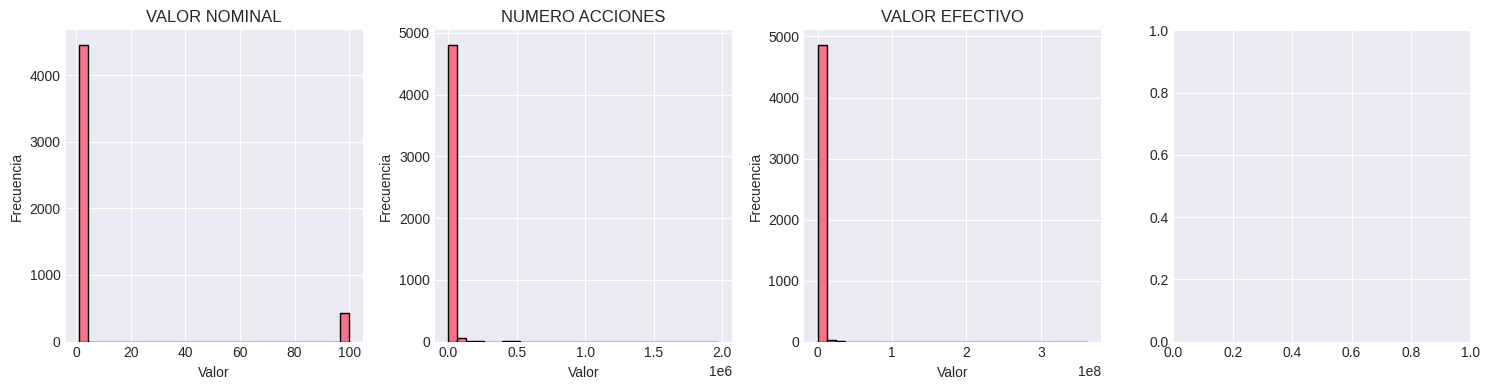

,VALOR NOMINAL,NUMERO ACCIONES,VALOR EFECTIVO
count,4883.000000,4.883000e+03,4.883000e+03
mean,9.808929,8.083562e+03,5.138448e+05
std,28.102700,4.455361e+04,6.005448e+06
min,1.000000,1.000000e+00,3.900000e+01
25%,1.000000,3.000000e+02,2.996000e+03
50%,1.000000,1.197000e+03,1.850000e+04
75%,1.000000,5.046000e+03,1.277475e+05
max,100.000000,1.971281e+06,3.627157e+08


In [45]:
# Grupo 1: Variables 1-3
vars_grupo1 = var_numericas[0:4]
print(f"Grupo 1: {vars_grupo1}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, var in enumerate(vars_grupo1):
    if i < len(vars_grupo1):
        bd_modelo[var].hist(bins=30, ax=axes[i], edgecolor='black')
        axes[i].set_title(var)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
    else:
        axes[i].axis('off') # Turn off extra subplots if any
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
bd_modelo[vars_grupo1].describe()

FEATURE ENGINEERING

In [46]:
# Paso 1: Agregar por emisor + día (de transacción a serie de tiempo diaria)
bd_diario = (
    bd_modelo
    .groupby(["EMISOR", "FECHA"])
    .agg(
        precio_promedio = ("PRECIO", "mean"),
        precio_max      = ("PRECIO", "max"),
        precio_min      = ("PRECIO", "min"),
        n_transacciones = ("PRECIO", "count"),
        valor_efectivo  = ("VALOR EFECTIVO", "sum"),
        num_acciones    = ("NUMERO ACCIONES", "sum")
    )
    .reset_index()
    .sort_values(["EMISOR", "FECHA"])
)

print(f"Shape diario: {bd_diario.shape}")
print(f"\nEjemplo Favorita:")
print(bd_diario[bd_diario["EMISOR"] == "CORPORACION FAVORITA C.A."].head(10))

Shape diario: (3705, 8)

Ejemplo Favorita:
                         EMISOR      FECHA  precio_promedio  precio_max  \
2280  CORPORACION FAVORITA C.A. 2025-01-06       188.000000       188.0   
2281  CORPORACION FAVORITA C.A. 2025-01-07              NaN         NaN   
2282  CORPORACION FAVORITA C.A. 2025-01-08       188.000000       188.0   
2283  CORPORACION FAVORITA C.A. 2025-01-09       188.727273       189.0   
2284  CORPORACION FAVORITA C.A. 2025-01-10       187.750000       188.0   
2285  CORPORACION FAVORITA C.A. 2025-01-13       188.000000       188.0   
2286  CORPORACION FAVORITA C.A. 2025-01-14       187.500000       188.0   
2287  CORPORACION FAVORITA C.A. 2025-01-15       154.000000       188.0   
2288  CORPORACION FAVORITA C.A. 2025-01-16       159.958333       189.0   
2289  CORPORACION FAVORITA C.A. 2025-01-17              NaN         NaN   

      precio_min  n_transacciones  valor_efectivo  num_acciones  
2280       188.0                2        371770.0        5807.0  

In [47]:
# Paso 2: Variable objetivo — retorno del siguiente período
bd_diario["precio_siguiente"] = bd_diario.groupby("EMISOR")["precio_promedio"].shift(-1)

bd_diario["retorno"] = (
    (bd_diario["precio_siguiente"] - bd_diario["precio_promedio"])
    / bd_diario["precio_promedio"]
)

# TARGET clasificación: 1 = sube, 0 = baja o igual
bd_diario["TARGET"] = (bd_diario["retorno"] > 0).astype(int)

print(f"\nBalance del TARGET:")
print(bd_diario["TARGET"].value_counts(normalize=True).round(3))


Balance del TARGET:
TARGET
0    0.89
1    0.11
Name: proportion, dtype: float64


**OBSERVACIÓN**: TARGET DESBALANCEADO

In [48]:
# Paso 3: Features técnicos (ventanas móviles)
for emisor_group in [bd_diario]:
    g = bd_diario.groupby("EMISOR")["precio_promedio"]

    # Medias móviles
    bd_diario["MA_7"]  = g.transform(lambda x: x.rolling(7,  min_periods=1).mean())
    bd_diario["MA_14"] = g.transform(lambda x: x.rolling(14, min_periods=1).mean())
    bd_diario["MA_30"] = g.transform(lambda x: x.rolling(30, min_periods=1).mean())

    # Volatilidad rolling
    bd_diario["vol_7"]  = g.transform(lambda x: x.rolling(7,  min_periods=2).std())
    bd_diario["vol_14"] = g.transform(lambda x: x.rolling(14, min_periods=2).std())

    # Momentum (precio hoy vs hace N días)
    bd_diario["momentum_7"]  = g.transform(lambda x: x.pct_change(7))
    bd_diario["momentum_14"] = g.transform(lambda x: x.pct_change(14))

    # Posición relativa (¿está caro o barato vs su media?)
    bd_diario["precio_vs_MA7"]  = bd_diario["precio_promedio"] / bd_diario["MA_7"]  - 1
    bd_diario["precio_vs_MA30"] = bd_diario["precio_promedio"] / bd_diario["MA_30"] - 1

print(f"\nFeatures creados:")
print(bd_diario.columns.tolist())
print(f"\nShape final: {bd_diario.shape}")


Features creados:
['EMISOR', 'FECHA', 'precio_promedio', 'precio_max', 'precio_min', 'n_transacciones', 'valor_efectivo', 'num_acciones', 'precio_siguiente', 'retorno', 'TARGET', 'MA_7', 'MA_14', 'MA_30', 'vol_7', 'vol_14', 'momentum_7', 'momentum_14', 'precio_vs_MA7', 'precio_vs_MA30']

Shape final: (3705, 20)


In [49]:
# ¿Por qué tan desbalanceado? Revisar retornos
print(bd_diario["retorno"].describe())
print(f"\nRetornos positivos: {(bd_diario['retorno'] > 0).sum()}")
print(f"Retornos = 0:       {(bd_diario['retorno'] == 0).sum()}")
print(f"Retornos negativos: {(bd_diario['retorno'] < 0).sum()}")
print(f"Retornos NaN:       {bd_diario['retorno'].isna().sum()}")

count    936.000000
mean       0.773828
std        5.848372
min       -0.990741
25%       -0.011615
50%        0.000000
75%        0.016102
max      104.000000
Name: retorno, dtype: float64

Retornos positivos: 409
Retornos = 0:       169
Retornos negativos: 358
Retornos NaN:       2769


ELIMINAR

In [50]:
# Paso 1: Eliminar NaN de retorno y TARGET
bd_diario_clean = bd_diario.dropna(subset=["retorno", "precio_siguiente"]).copy()

print(f"Registros antes: {len(bd_diario)}")
print(f"Registros después: {len(bd_diario_clean)}")
print(f"\nRetornos positivos: {(bd_diario_clean['retorno'] > 0).sum()}")
print(f"Retornos = 0:       {(bd_diario_clean['retorno'] == 0).sum()}")
print(f"Retornos negativos: {(bd_diario_clean['retorno'] < 0).sum()}")

Registros antes: 3705
Registros después: 936

Retornos positivos: 409
Retornos = 0:       169
Retornos negativos: 358


In [51]:
# Paso 2: Redefinir TARGET ignorando días neutros
bd_diario_clean = bd_diario_clean[bd_diario_clean["retorno"] != 0].copy()

bd_diario_clean["TARGET"] = (bd_diario_clean["retorno"] > 0).astype(int)

print(f"\nShape final: {bd_diario_clean.shape}")
print(f"\nBalance TARGET:")
print(bd_diario_clean["TARGET"].value_counts())
print(bd_diario_clean["TARGET"].value_counts(normalize=True).round(3))


Shape final: (767, 20)

Balance TARGET:
TARGET
1    409
0    358
Name: count, dtype: int64
TARGET
1    0.533
0    0.467
Name: proportion, dtype: float64


In [52]:
# Paso 3: Verificar max retorno = 104 (sospechoso)
print("\nRetornos extremos > 1 (>100%):")
print(bd_diario_clean[bd_diario_clean["retorno"] > 1][
    ["EMISOR", "FECHA", "precio_promedio", "precio_siguiente", "retorno"]
])


Retornos extremos > 1 (>100%):
                                       EMISOR      FECHA  precio_promedio  \
74                     BANCO BOLIVARIANO C.A. 2025-04-23        11.000000   
96                     BANCO BOLIVARIANO C.A. 2025-05-27         1.000000   
145                    BANCO BOLIVARIANO C.A. 2025-08-04        11.000000   
295   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-01-20         9.000000   
301   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-01-28         1.000000   
368   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-05-07         9.000000   
373   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-05-14        25.250000   
387   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-06-04        27.250000   
392   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-06-11         8.000000   
400   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-06-23         8.000000   
414   BANCO DE LA PRODUCCION S.A . PRODUBANCO 2025-07-11         8.000000   
434   BANCO DE LA PRODUCCION S.A . PRODUBANC

In [53]:
# Ver cuántos días de gap hay entre transacciones consecutivas por emisor
bd_diario_clean = bd_diario_clean.sort_values(["EMISOR", "FECHA"])

bd_diario_clean["dias_gap"] = bd_diario_clean.groupby("EMISOR")["FECHA"].diff().dt.days

print("Distribución de gaps entre transacciones:")
print(bd_diario_clean["dias_gap"].describe())
print(f"\nGaps > 7 días: {(bd_diario_clean['dias_gap'] > 7).sum()}")
print(f"Gaps > 30 días: {(bd_diario_clean['dias_gap'] > 30).sum()}")

# Ver gaps grandes en los emisores problemáticos
print("\nGaps grandes por emisor:")
print(bd_diario_clean[bd_diario_clean["dias_gap"] > 7].groupby("EMISOR")["dias_gap"].describe())

Distribución de gaps entre transacciones:
count    754.000000
mean       5.230769
std       11.788973
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max      104.000000
Name: dias_gap, dtype: float64

Gaps > 7 días: 108
Gaps > 30 días: 29

Gaps grandes por emisor:
                                         count       mean        std   min  \
EMISOR                                                                       
BANCO BOLIVARIANO C.A.                     9.0  35.000000  27.816362   8.0   
BANCO DE LA PRODUCCION S.A . PRODUBANCO   10.0  15.100000  10.928556   8.0   
BANCO DEL AUSTRO                           4.0  44.250000  37.562171   8.0   
BANCO GUAYAQUIL S.A.                       8.0  11.750000   3.327376   8.0   
BANCO PICHINCHA C.A.                      14.0  22.857143  19.532447   8.0   
BOLSA DE VALORES DE GUAYAQUIL              8.0  28.125000  26.454476   8.0   
BOLSA DE VALORES DE QUITO                  8.0  45.875000  35.510310   8.0   


BALANCEAMOS EL TRAGET

In [54]:
# Recalcular gap hacia adelante
bd_diario_clean = bd_diario_clean.sort_values(["EMISOR", "FECHA"]).copy()
bd_diario_clean["gap_siguiente"] = bd_diario_clean.groupby("EMISOR")["dias_gap"].shift(-1)

# Filtrar: solo retornos con gap <= 7 días (semana hábil máxima)
bd_diario_valid = bd_diario_clean[
    bd_diario_clean["gap_siguiente"] <= 7
].copy()

# Eliminar retornos extremos residuales (> 50% en un día = imposible en BVQ)
bd_diario_valid = bd_diario_valid[
    bd_diario_valid["retorno"].abs() <= 0.5
].copy()

# Eliminar neutros y redefinir TARGET
bd_diario_valid = bd_diario_valid[bd_diario_valid["retorno"] != 0].copy()
bd_diario_valid["TARGET"] = (bd_diario_valid["retorno"] > 0).astype(int)

print(f"Registros finales: {len(bd_diario_valid)}")
print(f"Emisores: {bd_diario_valid['EMISOR'].nunique()}")
print(f"\nBalance TARGET:")
print(bd_diario_valid["TARGET"].value_counts())
print(bd_diario_valid["TARGET"].value_counts(normalize=True).round(3))

print(f"\nRetornos extremos restantes (>50%):")
print((bd_diario_valid["retorno"].abs() > 0.5).sum())

print(f"\nRegistros por emisor:")
print(bd_diario_valid.groupby("EMISOR").size().sort_values(ascending=False))

Registros finales: 498
Emisores: 10

Balance TARGET:
TARGET
1    257
0    241
Name: count, dtype: int64
TARGET
1    0.516
0    0.484
Name: proportion, dtype: float64

Retornos extremos restantes (>50%):
0

Registros por emisor:
EMISOR
CORPORACION FAVORITA C.A.                  210
BANCO GUAYAQUIL S.A.                       128
BANCO DE LA PRODUCCION S.A . PRODUBANCO     75
BANCO PICHINCHA C.A.                        32
CERVECERIA NACIONAL CN S A                  14
BOLSA DE VALORES DE QUITO                   11
HOLCIM ECUADOR S.A.                         10
INVERSANCARLOS                               9
BANCO BOLIVARIANO C.A.                       6
BOLSA DE VALORES DE GUAYAQUIL                3
BANCO DEL AUSTRO                             0
MUTUALISTA PICHINCHA                         0
SAN CARLOS SOC. AGR. IND.                    0
dtype: int64


AGREGO MÁS LIBRERIAS PARA EL MODELO QUE VOY A IMPLEMENTAR

In [58]:
# Agregar a tus imports iniciales
from sklearn.model_selection import TimeSeriesSplit  # ya deberías tenerla
from sklearn.preprocessing import StandardScaler     # ya deberías tenerla
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Para el backtesting
import matplotlib.pyplot as plt  # ya la tienes

In [59]:
# Crear bd_final con los 4 emisores con datos suficientes
emisores_suficientes = [
    "CORPORACION FAVORITA C.A.",
    "BANCO GUAYAQUIL S.A.",
    "BANCO DE LA PRODUCCION S.A . PRODUBANCO",
    "BANCO PICHINCHA C.A.",
]

bd_final = bd_diario_valid[
    bd_diario_valid["EMISOR"].isin(emisores_suficientes)
].copy()

# Limpiar categorías vacías y encodear
bd_final["EMISOR"] = bd_final["EMISOR"].cat.remove_unused_categories()
bd_final["EMISOR_cod"] = bd_final["EMISOR"].cat.codes

# Transformación logarítmica si no está hecha
bd_final["log_valor_efectivo"] = np.log1p(bd_final["valor_efectivo"])
bd_final["log_num_acciones"]   = np.log1p(bd_final["num_acciones"])

print(f"Shape: {bd_final.shape}")
print(f"\nEmisores:")
print(bd_final["EMISOR"].value_counts())
print(f"\nBalance TARGET:")
print(bd_final["TARGET"].value_counts(normalize=True).round(3))

Shape: (445, 25)

Emisores:
EMISOR
CORPORACION FAVORITA C.A.                  210
BANCO GUAYAQUIL S.A.                       128
BANCO DE LA PRODUCCION S.A . PRODUBANCO     75
BANCO PICHINCHA C.A.                        32
Name: count, dtype: int64

Balance TARGET:
TARGET
1    0.519
0    0.481
Name: proportion, dtype: float64


In [60]:
# Verificar que bd_final tenga todo lo necesario
features = [
    "MA_7", "MA_14", "MA_30",
    "vol_7", "vol_14",
    "momentum_7", "momentum_14",
    "precio_vs_MA7", "precio_vs_MA30",
    "log_valor_efectivo",
    "log_num_acciones",
    "n_transacciones",
    "EMISOR_cod"
]

print("Shape:", bd_final.shape)
print("\nFeatures disponibles:")
print([f for f in features if f in bd_final.columns])
print("\nFeatures FALTANTES:")
print([f for f in features if f not in bd_final.columns])
print("\nNaN por columna:")
print(bd_final[features].isna().sum())
print("\nBalance TARGET:")
print(bd_final["TARGET"].value_counts(normalize=True).round(3))

Shape: (445, 25)

Features disponibles:
['MA_7', 'MA_14', 'MA_30', 'vol_7', 'vol_14', 'momentum_7', 'momentum_14', 'precio_vs_MA7', 'precio_vs_MA30', 'log_valor_efectivo', 'log_num_acciones', 'n_transacciones', 'EMISOR_cod']

Features FALTANTES:
[]

NaN por columna:
MA_7                   0
MA_14                  0
MA_30                  0
vol_7                  0
vol_14                 0
momentum_7             6
momentum_14           13
precio_vs_MA7          0
precio_vs_MA30         0
log_valor_efectivo     0
log_num_acciones       0
n_transacciones        0
EMISOR_cod             0
dtype: int64

Balance TARGET:
TARGET
1    0.519
0    0.481
Name: proportion, dtype: float64


ELIMINAMOS NaN DE MOMENTUM

In [61]:
# Eliminar los 19 NaN de momentum (son los primeros días de cada emisor)
bd_final = bd_final.dropna(subset=["momentum_7", "momentum_14"]).copy()

print(f"Shape final: {bd_final.shape}")
print(f"\nNaN restantes:")
print(bd_final[features].isna().sum().sum())
print(f"\nBalance TARGET:")
print(bd_final["TARGET"].value_counts(normalize=True).round(3))
print(f"\nRegistros por emisor:")
print(bd_final["EMISOR"].value_counts())

Shape final: (432, 25)

NaN restantes:
0

Balance TARGET:
TARGET
1    0.521
0    0.479
Name: proportion, dtype: float64

Registros por emisor:
EMISOR
CORPORACION FAVORITA C.A.                  200
BANCO GUAYAQUIL S.A.                       127
BANCO DE LA PRODUCCION S.A . PRODUBANCO     73
BANCO PICHINCHA C.A.                        32
Name: count, dtype: int64


# **FASE 4.- MODELADO**

In [62]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# ── 1. Ordenar por tiempo (CRÍTICO en series temporales) ──────────────────
bd_final = bd_final.sort_values(["EMISOR", "FECHA"]).reset_index(drop=True)

X = bd_final[features]
y = bd_final["TARGET"]

# ── 2. Split temporal 80/20 (NO aleatorio) ───────────────────────────────
split_idx = int(len(bd_final) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Período train: {bd_final['FECHA'].iloc[0].date()} → {bd_final['FECHA'].iloc[split_idx-1].date()}")
print(f"Período test:  {bd_final['FECHA'].iloc[split_idx].date()} → {bd_final['FECHA'].iloc[-1].date()}")

# ── 3. Escalar ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 4. Entrenar 3 modelos ─────────────────────────────────────────────────
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric="logloss", verbosity=0),
}

resultados = {}

for nombre, modelo in modelos.items():
    if nombre == "Logistic Regression":
        modelo.fit(X_train_sc, y_train)
        y_pred  = modelo.predict(X_test_sc)
        y_proba = modelo.predict_proba(X_test_sc)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    resultados[nombre] = {
        "modelo":  modelo,
        "y_pred":  y_pred,
        "y_proba": y_proba,
        "auc":     auc
    }

    print(f"\n{'='*50}")
    print(f"  {nombre}  —  AUC: {auc:.3f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=["Baja (0)", "Sube (1)"]))

Train: (345, 13) | Test: (87, 13)
Período train: 2025-03-18 → 2025-09-01
Período test:  2025-09-02 → 2026-02-25

  Logistic Regression  —  AUC: 0.564
              precision    recall  f1-score   support

    Baja (0)       0.55      0.41      0.47        44
    Sube (1)       0.52      0.65      0.58        43

    accuracy                           0.53        87
   macro avg       0.53      0.53      0.52        87
weighted avg       0.53      0.53      0.52        87


  Random Forest  —  AUC: 0.513
              precision    recall  f1-score   support

    Baja (0)       0.54      0.82      0.65        44
    Sube (1)       0.60      0.28      0.38        43

    accuracy                           0.55        87
   macro avg       0.57      0.55      0.51        87
weighted avg       0.57      0.55      0.52        87


  XGBoost  —  AUC: 0.531
              precision    recall  f1-score   support

    Baja (0)       0.54      0.84      0.66        44
    Sube (1)       0.63      

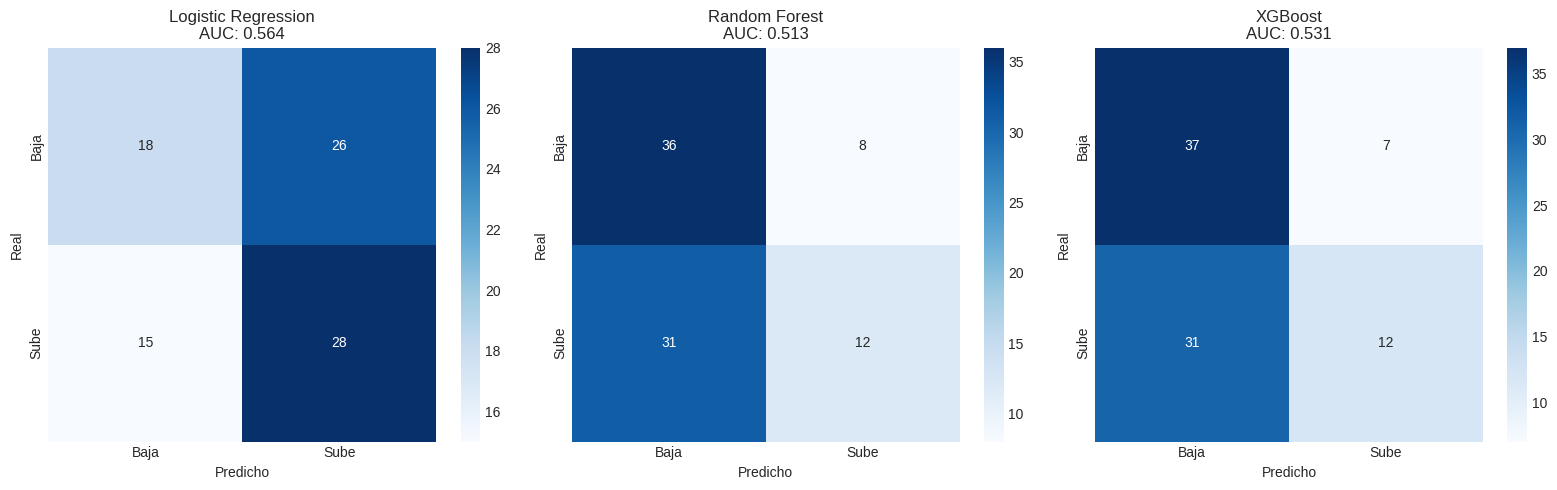


📊 RESUMEN COMPARATIVO:
Modelo                       AUC
---------------------------------
Logistic Regression        0.564
Random Forest              0.513
XGBoost                    0.531


In [63]:
# ── 5. Comparar modelos visualmente ──────────────────────────────────────
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (nombre, res) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i],
                xticklabels=["Baja", "Sube"],
                yticklabels=["Baja", "Sube"],
                cmap="Blues")
    axes[i].set_title(f"{nombre}\nAUC: {res['auc']:.3f}")
    axes[i].set_ylabel("Real")
    axes[i].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

# Resumen comparativo
print("\n📊 RESUMEN COMPARATIVO:")
print(f"{'Modelo':<25} {'AUC':>6}")
print("-" * 33)
for nombre, res in resultados.items():
    print(f"{nombre:<25} {res['auc']:>6.3f}")

VER DIAGNOSTICO DE CAUSAS

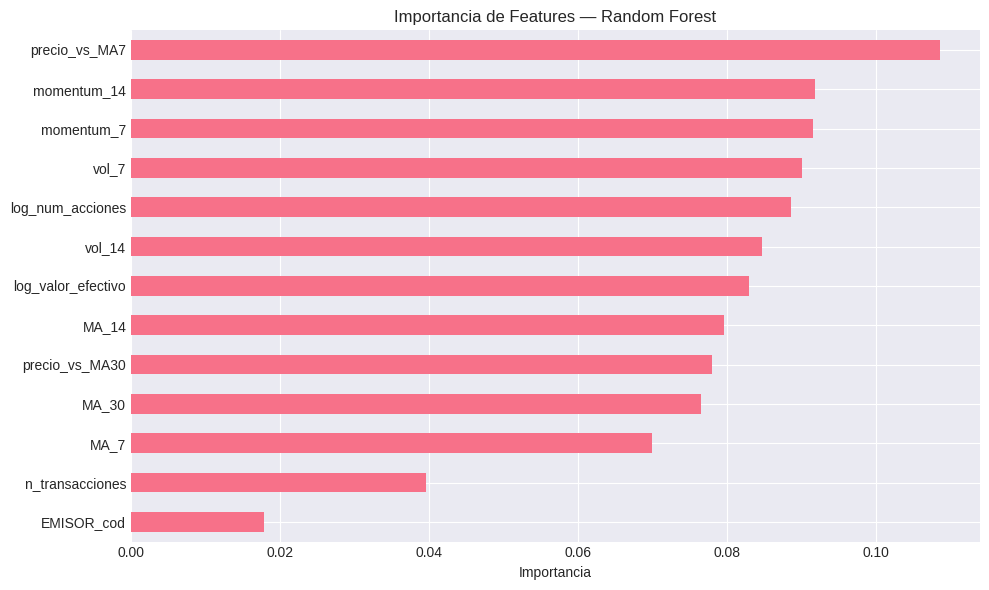

Train: 345 registros
Test:  87 registros

Período test:
count                               87
mean     2025-11-28 16:49:39.310344704
min                2025-09-02 00:00:00
25%                2025-10-04 12:00:00
50%                2025-12-03 00:00:00
75%                2026-01-15 12:00:00
max                2026-02-25 00:00:00
Name: FECHA, dtype: object


In [64]:
# 1. Ver importancia de features en Random Forest
import pandas as pd
import matplotlib.pyplot as plt

rf = resultados["Random Forest"]["modelo"]
importancias = pd.Series(rf.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind="barh")
plt.title("Importancia de Features — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# 2. Ver si el problema es el tamaño del dataset
print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

# 3. Ver distribución temporal del test
print(f"\nPeríodo test:")
print(bd_final.iloc[split_idx:]["FECHA"].describe())

PROBLEMA ES QUE EXISTEN MUY POCOS DATOS PARA TODOS ESOS FEATURES

In [65]:
# Modelo solo con Corporación Favorita
bd_favorita = bd_final[
    bd_final["EMISOR"] == "CORPORACION FAVORITA C.A."
].copy().reset_index(drop=True)

# Agregar features adicionales
bd_favorita["precio_range"]  = (bd_favorita["precio_max"] - bd_favorita["precio_min"]) / bd_favorita["precio_promedio"]
bd_favorita["retorno_lag1"]  = bd_favorita["retorno"].shift(1)
bd_favorita["retorno_lag2"]  = bd_favorita["retorno"].shift(2)
bd_favorita["retorno_lag3"]  = bd_favorita["retorno"].shift(3)
bd_favorita["vol_trend"]     = bd_favorita["vol_7"] / bd_favorita["vol_14"]

bd_favorita = bd_favorita.dropna().copy()

features_v2 = [
    "MA_7", "MA_14", "MA_30",
    "vol_7", "vol_14", "vol_trend",
    "momentum_7", "momentum_14",
    "precio_vs_MA7", "precio_vs_MA30",
    "precio_range",
    "retorno_lag1", "retorno_lag2", "retorno_lag3",
    "log_valor_efectivo", "log_num_acciones",
    "n_transacciones"
]

X = bd_favorita[features_v2]
y = bd_favorita["TARGET"]

# Split temporal 80/20
split_idx = int(len(bd_favorita) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Shape Favorita: {bd_favorita.shape}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"\nBalance TARGET train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nBalance TARGET test:")
print(y_test.value_counts(normalize=True).round(3))

Shape Favorita: (197, 30)
Train: 157 | Test: 40

Balance TARGET train:
TARGET
0    0.522
1    0.478
Name: proportion, dtype: float64

Balance TARGET test:
TARGET
1    0.525
0    0.475
Name: proportion, dtype: float64


In [66]:
# Reentrenar los 3 modelos
scaler2 = StandardScaler()
X_train_sc2 = scaler2.fit_transform(X_train)
X_test_sc2  = scaler2.transform(X_test)

modelos_v2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, random_state=42,
                                              eval_metric="logloss", verbosity=0),
}

resultados_v2 = {}

for nombre, modelo in modelos_v2.items():
    if nombre == "Logistic Regression":
        modelo.fit(X_train_sc2, y_train)
        y_pred  = modelo.predict(X_test_sc2)
        y_proba = modelo.predict_proba(X_test_sc2)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    resultados_v2[nombre] = {
        "modelo": modelo, "y_pred": y_pred,
        "y_proba": y_proba, "auc": auc
    }
    print(f"\n{'='*50}")
    print(f"  {nombre}  —  AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred,
          target_names=["Baja (0)", "Sube (1)"]))


  Logistic Regression  —  AUC: 0.461
              precision    recall  f1-score   support

    Baja (0)       0.43      0.68      0.53        19
    Sube (1)       0.40      0.19      0.26        21

    accuracy                           0.42        40
   macro avg       0.42      0.44      0.39        40
weighted avg       0.42      0.42      0.39        40


  Random Forest  —  AUC: 0.588
              precision    recall  f1-score   support

    Baja (0)       0.53      0.95      0.68        19
    Sube (1)       0.83      0.24      0.37        21

    accuracy                           0.57        40
   macro avg       0.68      0.59      0.52        40
weighted avg       0.69      0.57      0.52        40


  XGBoost  —  AUC: 0.584
              precision    recall  f1-score   support

    Baja (0)       0.52      0.89      0.65        19
    Sube (1)       0.71      0.24      0.36        21

    accuracy                           0.55        40
   macro avg       0.61      0.5

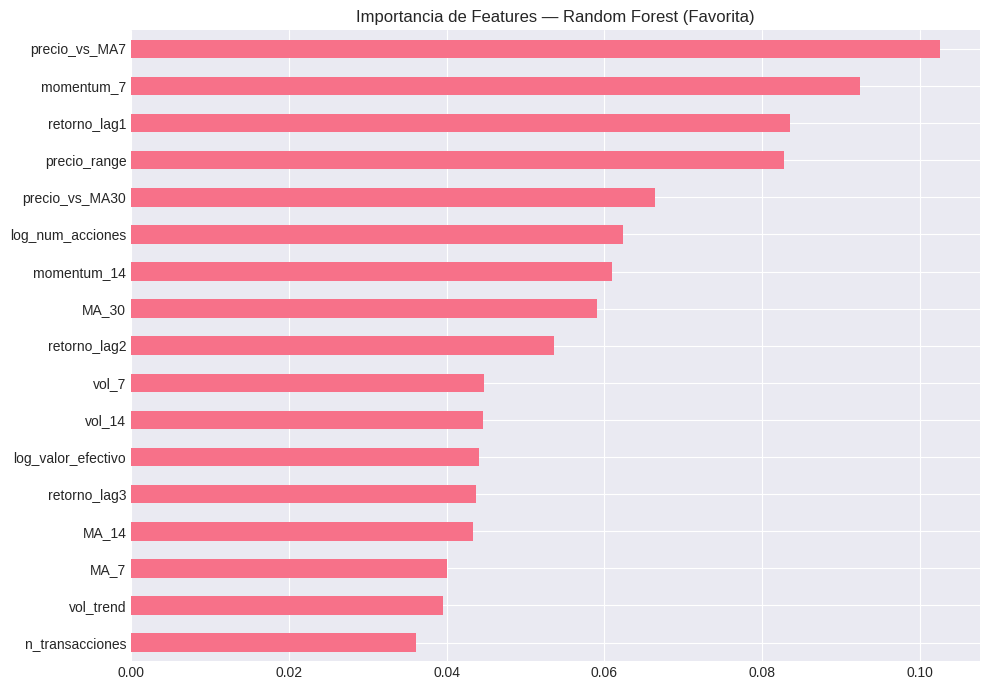


📊 RESUMEN COMPARATIVO v2 (solo Favorita):
Modelo                       AUC
---------------------------------
Logistic Regression        0.461
Random Forest              0.588
XGBoost                    0.584


In [67]:
# Importancia de features
rf_v2 = resultados_v2["Random Forest"]["modelo"]
importancias = pd.Series(rf_v2.feature_importances_, index=features_v2)
importancias.sort_values(ascending=True).plot(
    kind="barh", figsize=(10, 7),
    title="Importancia de Features — Random Forest (Favorita)"
)
plt.tight_layout()
plt.show()

print("\n📊 RESUMEN COMPARATIVO v2 (solo Favorita):")
print(f"{'Modelo':<25} {'AUC':>6}")
print("-" * 33)
for nombre, res in resultados_v2.items():
    print(f"{nombre:<25} {res['auc']:>6.3f}")

OPTIMIZACION CON GRIDSEARCH

In [69]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)  # menos folds

# ── Random Forest ligero ──────────────────────────────────────────────────
param_dist_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [3, 5, 7],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"]
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist_rf,
    n_iter=20,          # solo 20 combinaciones aleatorias
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=0
)
search_rf.fit(X_train, y_train)
mejor_rf   = search_rf.best_estimator_
auc_rf     = roc_auc_score(y_test, mejor_rf.predict_proba(X_test)[:, 1])

# ── XGBoost ligero ────────────────────────────────────────────────────────
param_dist_xgb = {
    "n_estimators":  [100, 200],
    "max_depth":     [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample":     [0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_dist_xgb,
    n_iter=20,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=0
)
search_xgb.fit(X_train, y_train)
mejor_xgb  = search_xgb.best_estimator_
auc_xgb    = roc_auc_score(y_test, mejor_xgb.predict_proba(X_test)[:, 1])

# ── Comparación ───────────────────────────────────────────────────────────
print("📊 RESULTADOS TUNING:")
print(f"{'Modelo':<25} {'AUC':>6}")
print("-" * 33)
print(f"{'Random Forest':<25} {auc_rf:>6.3f}  params: {search_rf.best_params_}")
print(f"{'XGBoost':<25} {auc_xgb:>6.3f}  params: {search_xgb.best_params_}")
print(f"\n✅ Mejor modelo: {'Random Forest' if auc_rf >= auc_xgb else 'XGBoost'}")

📊 RESULTADOS TUNING:
Modelo                       AUC
---------------------------------
Random Forest              0.584  params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 7}
XGBoost                    0.652  params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01}

✅ Mejor modelo: XGBoost


EVALUACION FINAL + BACKTESTING

📊 REPORTE FINAL — XGBoost
              precision    recall  f1-score   support

    Baja (0)       0.55      0.95      0.69        19
    Sube (1)       0.86      0.29      0.43        21

    accuracy                           0.60        40
   macro avg       0.70      0.62      0.56        40
weighted avg       0.71      0.60      0.55        40



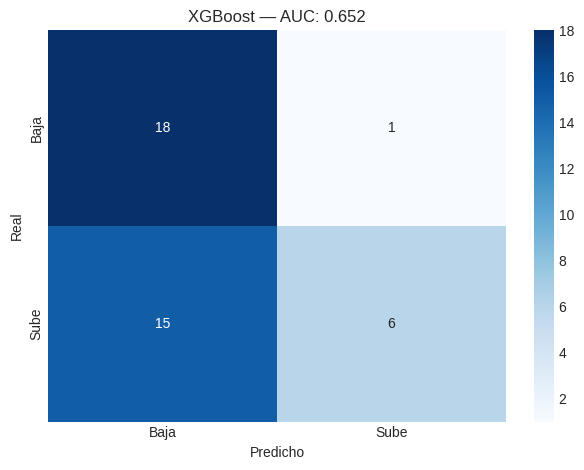

In [70]:
# ── 1. Evaluación completa del mejor modelo ───────────────────────────────
y_pred_final  = mejor_xgb.predict(X_test)
y_proba_final = mejor_xgb.predict_proba(X_test)[:, 1]

print("📊 REPORTE FINAL — XGBoost")
print("="*50)
print(classification_report(y_test, y_pred_final,
      target_names=["Baja (0)", "Sube (1)"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Baja", "Sube"],
            yticklabels=["Baja", "Sube"],
            cmap="Blues")
plt.title(f"XGBoost — AUC: {auc_xgb:.3f}")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

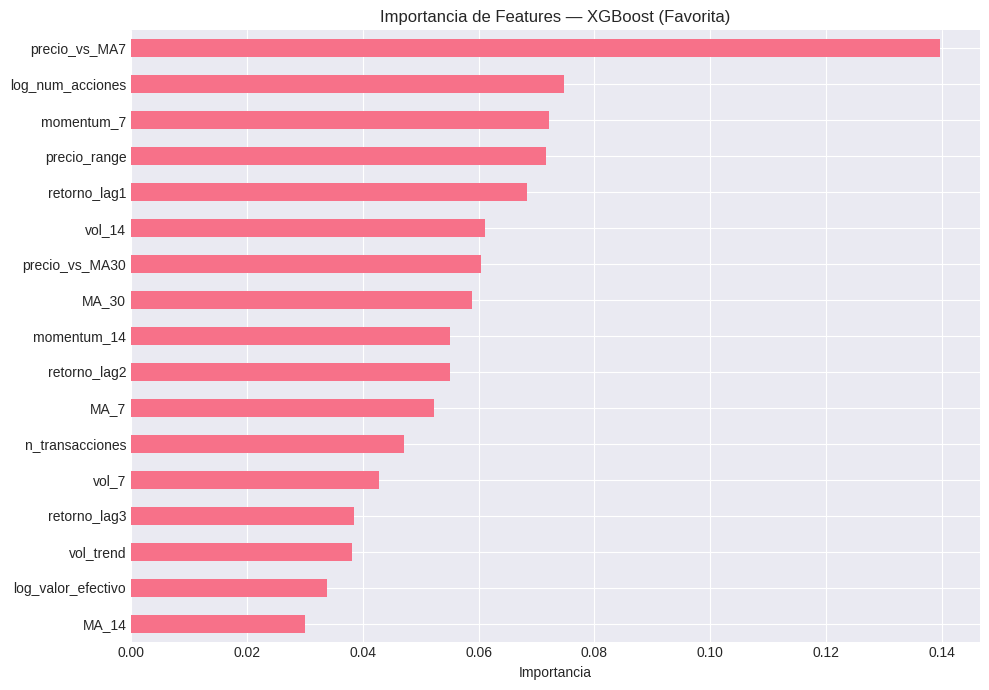

In [71]:
# ── 2. Importancia de features ────────────────────────────────────────────
importancias_xgb = pd.Series(
    mejor_xgb.feature_importances_,
    index=features_v2
).sort_values(ascending=True)

importancias_xgb.plot(kind="barh", figsize=(10, 7),
    title="Importancia de Features — XGBoost (Favorita)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


💰 RESULTADOS BACKTESTING — Corporación Favorita
Capital inicial:   $1,000.00
Capital final:     $1,272.20
Rentabilidad:      +27.22%
Operaciones:       2
Período:           2025-12-10 → 2026-02-25


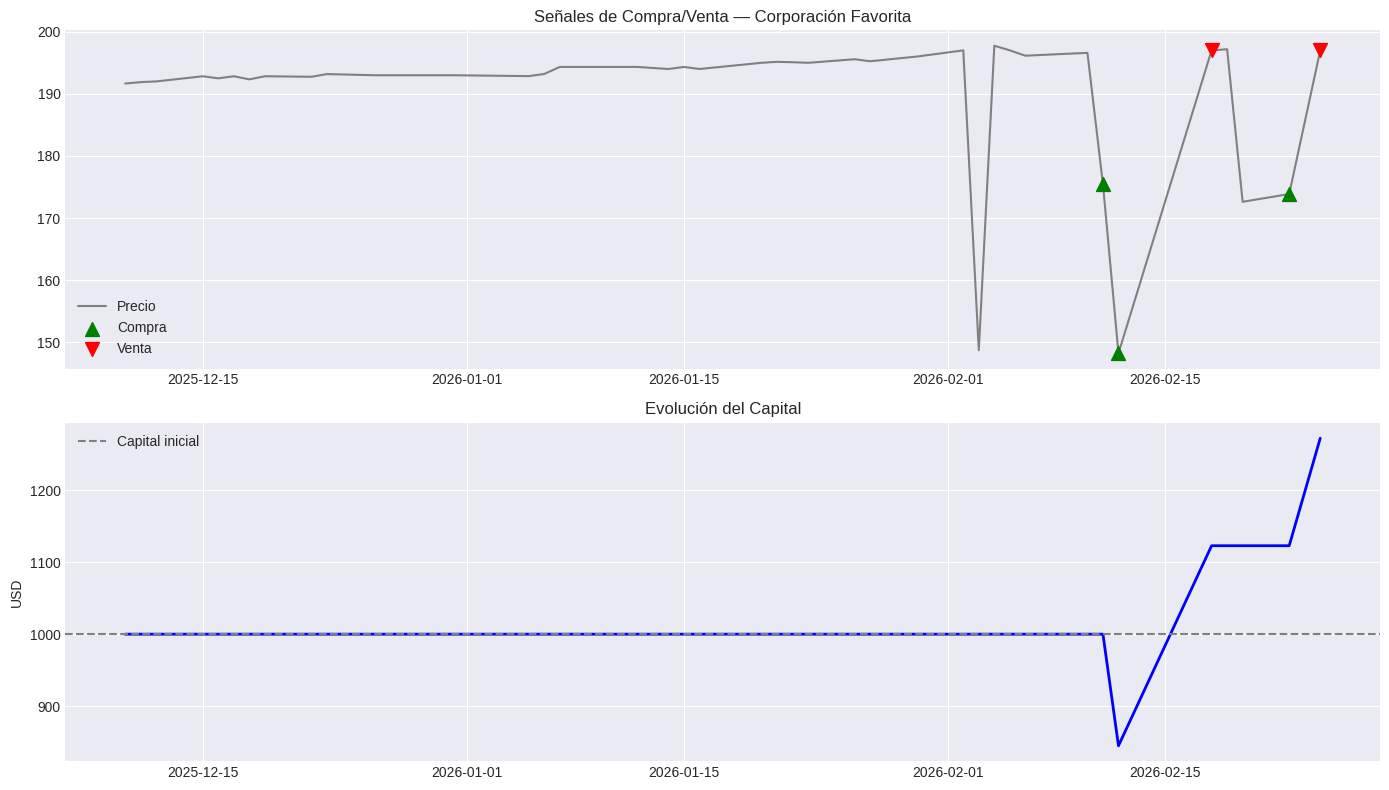


📋 DETALLE DE OPERACIONES:
     FECHA     PRECIO  PROB               ACCIÓN  CAPITAL
2026-02-11 175.444444 0.625              COMPRAR  1000.00
2026-02-12 148.250000 0.666              COMPRAR   845.00
2026-02-18 197.000000 0.341 VENDER (take profit)  1122.86
2026-02-23 173.875000 0.682              COMPRAR  1122.86
2026-02-25 197.000000 0.352 VENDER (take profit)  1272.20


In [72]:
# ── 3. Backtesting — simulación de compra/venta ───────────────────────────
bt = bd_favorita.iloc[split_idx:].copy().reset_index(drop=True)
bt["prob_sube"]  = y_proba_final
bt["prediccion"] = y_pred_final

UMBRAL     = 0.60   # solo operar si confianza > 60%
CAPITAL    = 1000   # USD iniciales
STOP_LOSS  = -0.05  # vender si pierde 5%
TAKE_PROFIT = 0.10  # vender si gana 10%

capital      = CAPITAL
en_posicion  = False
precio_compra = None
historial    = []

for _, row in bt.iterrows():
    precio = row["precio_promedio"]
    señal  = row["prediccion"]
    prob   = row["prob_sube"]
    fecha  = row["FECHA"]
    ganancia_actual = ((precio - precio_compra) / precio_compra) if en_posicion else 0

    accion = "MANTENER"

    # Lógica de VENTA
    if en_posicion:
        if ganancia_actual >= TAKE_PROFIT:
            accion = "VENDER (take profit)"
            capital *= (1 + ganancia_actual)
            en_posicion = False
        elif ganancia_actual <= STOP_LOSS:
            accion = "VENDER (stop loss)"
            capital *= (1 + ganancia_actual)
            en_posicion = False
        elif señal == 0 and prob < (1 - UMBRAL):
            accion = "VENDER (señal modelo)"
            capital *= (1 + ganancia_actual)
            en_posicion = False

    # Lógica de COMPRA
    if not en_posicion and señal == 1 and prob >= UMBRAL:
        accion = "COMPRAR"
        precio_compra = precio
        en_posicion = True

    historial.append({
        "FECHA":    fecha,
        "PRECIO":   precio,
        "PROB":     round(prob, 3),
        "ACCIÓN":   accion,
        "CAPITAL":  round(capital, 2)
    })

# Cerrar posición abierta al final
if en_posicion:
    ganancia_final = (bt.iloc[-1]["precio_promedio"] - precio_compra) / precio_compra
    capital *= (1 + ganancia_final)

df_bt = pd.DataFrame(historial)

# ── 4. Resultados del backtesting ─────────────────────────────────────────
rentabilidad = (capital - CAPITAL) / CAPITAL * 100
operaciones  = df_bt[df_bt["ACCIÓN"].str.contains("VENDER")].shape[0]

print(f"\n💰 RESULTADOS BACKTESTING — Corporación Favorita")
print(f"{'='*45}")
print(f"Capital inicial:   ${CAPITAL:,.2f}")
print(f"Capital final:     ${capital:,.2f}")
print(f"Rentabilidad:      {rentabilidad:+.2f}%")
print(f"Operaciones:       {operaciones}")
print(f"Período:           {bt['FECHA'].min().date()} → {bt['FECHA'].max().date()}")

# ── 5. Gráfico evolución del capital ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Precio con señales
axes[0].plot(df_bt["FECHA"], df_bt["PRECIO"], label="Precio", color="gray")
compras = df_bt[df_bt["ACCIÓN"] == "COMPRAR"]
ventas  = df_bt[df_bt["ACCIÓN"].str.contains("VENDER")]
axes[0].scatter(compras["FECHA"], compras["PRECIO"],
                marker="^", color="green", s=100, label="Compra", zorder=5)
axes[0].scatter(ventas["FECHA"], ventas["PRECIO"],
                marker="v", color="red", s=100, label="Venta", zorder=5)
axes[0].set_title("Señales de Compra/Venta — Corporación Favorita")
axes[0].legend()

# Evolución del capital
axes[1].plot(df_bt["FECHA"], df_bt["CAPITAL"], color="blue", linewidth=2)
axes[1].axhline(y=CAPITAL, color="gray", linestyle="--", label="Capital inicial")
axes[1].set_title("Evolución del Capital")
axes[1].set_ylabel("USD")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 6. Detalle de operaciones ─────────────────────────────────────────────
print("\n📋 DETALLE DE OPERACIONES:")
print(df_bt[df_bt["ACCIÓN"] != "MANTENER"].to_string(index=False))

Hay un bug en la lógica — el 12 compró nuevamente estando ya en posición. Corrijamos:

In [73]:
# Bug fix — agregar flag para evitar doble compra
# Y extender el backtesting a TODOS los emisores para comparar

def backtesting_emisor(bd_emisor, modelo, scaler_obj=None,
                        features_list=features_v2,
                        capital_inicial=1000,
                        umbral=0.60,
                        stop_loss=-0.05,
                        take_profit=0.10):

    # Split temporal
    split = int(len(bd_emisor) * 0.8)
    X_bt  = bd_emisor[features_list].iloc[split:]

    if scaler_obj:
        X_bt = scaler_obj.transform(X_bt)

    probs  = modelo.predict_proba(X_bt)[:, 1]
    preds  = modelo.predict(X_bt)

    bt = bd_emisor.iloc[split:].copy().reset_index(drop=True)
    bt["prob_sube"]  = probs
    bt["prediccion"] = preds

    capital       = capital_inicial
    en_posicion   = False
    precio_compra = None
    historial     = []

    for _, row in bt.iterrows():
        precio          = row["precio_promedio"]
        señal           = row["prediccion"]
        prob            = row["prob_sube"]
        fecha           = row["FECHA"]
        ganancia_actual = ((precio - precio_compra) / precio_compra) if en_posicion else 0
        accion          = "MANTENER"

        # VENTA
        if en_posicion:
            if ganancia_actual >= take_profit:
                accion      = f"VENDER ✅ take profit {ganancia_actual*100:+.1f}%"
                capital    *= (1 + ganancia_actual)
                en_posicion = False
            elif ganancia_actual <= stop_loss:
                accion      = f"VENDER ❌ stop loss {ganancia_actual*100:+.1f}%"
                capital    *= (1 + ganancia_actual)
                en_posicion = False
            elif señal == 0 and prob < (1 - umbral):
                accion      = f"VENDER ⚠️ señal modelo {ganancia_actual*100:+.1f}%"
                capital    *= (1 + ganancia_actual)
                en_posicion = False

        # COMPRA — solo si NO está en posición
        if not en_posicion and señal == 1 and prob >= umbral:
            accion        = "COMPRAR 🟢"
            precio_compra = precio
            en_posicion   = True

        historial.append({
            "FECHA":   fecha,
            "PRECIO":  round(precio, 2),
            "PROB":    round(prob, 3),
            "ACCIÓN":  accion,
            "CAPITAL": round(capital, 2)
        })

    # Cerrar posición abierta al final
    if en_posicion:
        g = (bt.iloc[-1]["precio_promedio"] - precio_compra) / precio_compra
        capital *= (1 + g)

    df_bt        = pd.DataFrame(historial)
    rentabilidad = (capital - capital_inicial) / capital_inicial * 100
    operaciones  = df_bt[df_bt["ACCIÓN"].str.contains("VENDER")].shape[0]

    return df_bt, capital, rentabilidad, operaciones


# ── Ejecutar para Favorita ────────────────────────────────────────────────
df_bt, capital_f, rent_f, ops_f = backtesting_emisor(bd_favorita, mejor_xgb)

print(f"💰 CORPORACIÓN FAVORITA")
print(f"   Capital final:  ${capital_f:,.2f}")
print(f"   Rentabilidad:   {rent_f:+.2f}%")
print(f"   Operaciones:    {ops_f}")

print(f"\n📋 DETALLE:")
print(df_bt[df_bt["ACCIÓN"] != "MANTENER"].to_string(index=False))

💰 CORPORACIÓN FAVORITA
   Capital final:  $1,272.20
   Rentabilidad:   +27.22%
   Operaciones:    2

📋 DETALLE:
     FECHA  PRECIO  PROB                      ACCIÓN  CAPITAL
2026-02-11  175.44 0.625                   COMPRAR 🟢  1000.00
2026-02-12  148.25 0.666                   COMPRAR 🟢   845.00
2026-02-18  197.00 0.341 VENDER ✅ take profit +32.9%  1122.86
2026-02-23  173.88 0.682                   COMPRAR 🟢  1122.86
2026-02-25  197.00 0.352 VENDER ✅ take profit +13.3%  1272.20


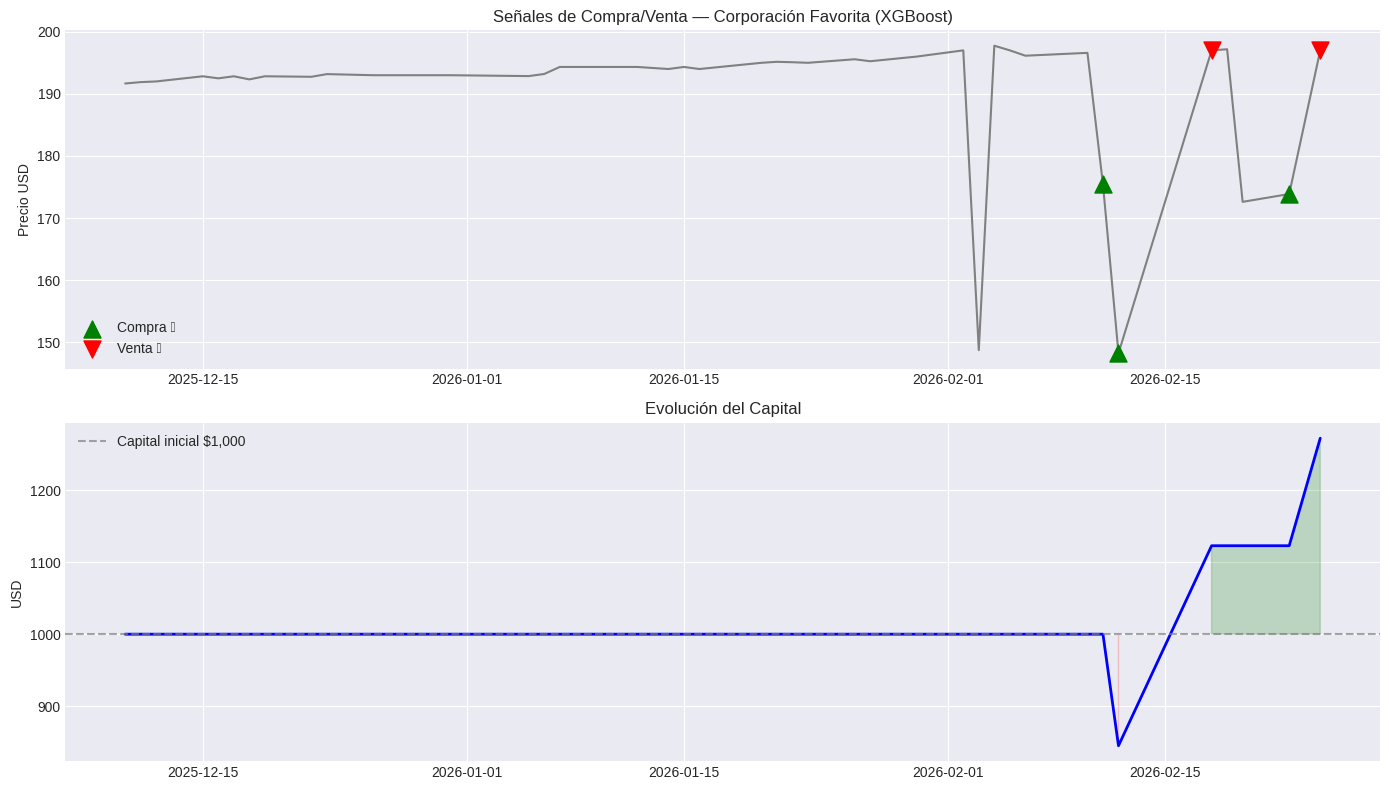

In [74]:
# ── Gráfico limpio ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Precio con señales
axes[0].plot(df_bt["FECHA"], df_bt["PRECIO"], color="gray", linewidth=1.5)
compras = df_bt[df_bt["ACCIÓN"].str.contains("COMPRAR")]
ventas  = df_bt[df_bt["ACCIÓN"].str.contains("VENDER")]
axes[0].scatter(compras["FECHA"], compras["PRECIO"],
                marker="^", color="green", s=150, label="Compra 🟢", zorder=5)
axes[0].scatter(ventas["FECHA"], ventas["PRECIO"],
                marker="v", color="red", s=150, label="Venta 🔴", zorder=5)
axes[0].set_title("Señales de Compra/Venta — Corporación Favorita (XGBoost)")
axes[0].set_ylabel("Precio USD")
axes[0].legend()

# Evolución capital
axes[1].plot(df_bt["FECHA"], df_bt["CAPITAL"], color="blue", linewidth=2)
axes[1].axhline(y=1000, color="gray", linestyle="--", alpha=0.7, label="Capital inicial $1,000")
axes[1].fill_between(df_bt["FECHA"], 1000, df_bt["CAPITAL"],
                      where=df_bt["CAPITAL"] >= 1000, alpha=0.2, color="green")
axes[1].fill_between(df_bt["FECHA"], 1000, df_bt["CAPITAL"],
                      where=df_bt["CAPITAL"] < 1000, alpha=0.2, color="red")
axes[1].set_title("Evolución del Capital")
axes[1].set_ylabel("USD")
axes[1].legend()

plt.tight_layout()
plt.show()